# Acoustic localization with `laplace-soundscape`

Importing libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import laplace_soundscape as lps

Importing data and setting hyperperameters

In [2]:
metadata = pd.read_csv("../results/fieldTest_metadata.csv")

df = pd.read_csv("../results/fieldTest_distances.csv")
DISTANCES = {
    (row.key1, row.key2): np.float64(row.value)
    for row in df.itertuples(index=False)
}
INPUT_EPSG = 4326
TARGET_EPSG = 32620
DISTANCE_ERROR = 0.5

## Microphone array reconstruction

The `AudiomothPosition` class compute mean and variance of audiomoth GPS position from recordings metadata.

In [3]:
AudiomothPosition = lps.audiomoth.AudiomothPosition
C1, _ = AudiomothPosition("../../../Data/test_localisation_20250808/C1/20250808","C1").summary(data_frame=True)
C2, _ = AudiomothPosition("../../../Data/test_localisation_20250808/C2/20250808","C2").summary(data_frame=True)
D1, _ = AudiomothPosition("../../../Data/test_localisation_20250808/D1/20250808","D1").summary(data_frame=True)
D2, _ = AudiomothPosition("../../../Data/test_localisation_20250808/D2/20250808","D2").summary(data_frame=True)
A1, _ = AudiomothPosition("../../../Data/test_localisation_20250808/A1/20250808","A1").summary(data_frame=True)
A2, _ = AudiomothPosition("../../../Data/test_localisation_20250808/A2/20250808","A2").summary(data_frame=True)
A3, _ = AudiomothPosition("../../../Data/test_localisation_20250808/A3/20250808","A3").summary(data_frame=True)
A4, _ = AudiomothPosition("../../../Data/test_localisation_20250808/A4/20250808","A4").summary(data_frame=True)
B1, _ = AudiomothPosition("../../../Data/test_localisation_20250808/B1/20250808","B1").summary(data_frame=True)

priors_gps = pd.concat([D1,C2,C1,D2,A1,A2,A3,A4,B1]).set_index("aru")
priors = lps.array.set_priors_crs(priors_gps, INPUT_EPSG, TARGET_EPSG)

For two points, we know the exact position from aerial imagery. We set informative (i.e. low standard deviation) priors for those two points. The coordinates have been copied from QGIS.

In [4]:
priors.loc["C1","lon_mu"], priors.loc["C1", "lat_mu"] = -139600.928, 5195963.201
priors.loc["C1","lon_sd"], priors.loc["C1", "lat_sd"] = 1, 1
priors.loc["C2","lon_mu"], priors.loc["C2", "lat_mu"] = -139556.983, 5195954.490
priors.loc["C2","lon_sd"], priors.loc["C2", "lat_sd"] = 1, 1

Then we can compute the posterior positions of the recorders.

In [5]:
array = lps.array.ArrayReconstruction(priors, DISTANCES, TARGET_EPSG, DISTANCE_ERROR)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [x, y]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


The `ArrayReconstruction` helps us to get information about prior and posterior arrays.

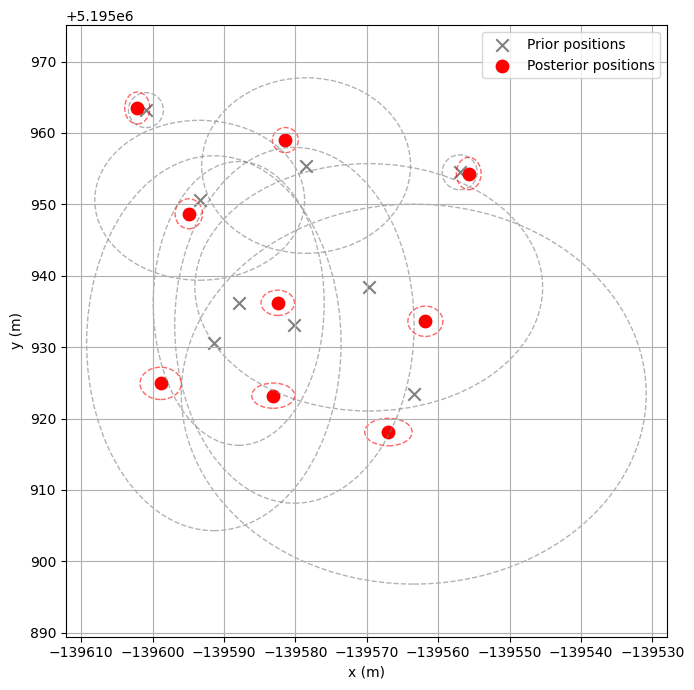

Prior positions:
                 x             y
aru                             
A1  -139578.497345  5.195955e+06
A2  -139569.720295  5.195938e+06
A3  -139580.134404  5.195933e+06
A4  -139593.403729  5.195951e+06
B1  -139587.939580  5.195936e+06
C1  -139600.928000  5.195963e+06
C2  -139556.983000  5.195954e+06
D1  -139591.416235  5.195931e+06
D2  -139563.420619  5.195923e+06
 
Posterior positions:
                 x             y
aru                             
A1  -139581.403017  5.195959e+06
A2  -139561.792135  5.195934e+06
A3  -139583.100912  5.195923e+06
A4  -139594.928504  5.195949e+06
B1  -139582.470118  5.195936e+06
C1  -139602.147210  5.195964e+06
C2  -139555.721379  5.195954e+06
D1  -139598.871518  5.195925e+06
D2  -139566.965780  5.195918e+06


In [6]:
array.get_distances()
array.plot()
print("Prior positions:")
print(array.prior_points)
print(" ")
print("Posterior positions:")
print(array.posterior_points)

## Sound localization

In [7]:
PATH="../../../Data/test_localisation_20250808/SYNC/"
FILES=os.listdir(PATH)
TIME_BUFFER=0.5

In [8]:
import ipywidgets as widgets

# Select recorders
recorders = widgets.SelectMultiple(
    options=array.names,
    value=[aru for aru in array.names if aru != "A4"],
    rows=10,
    disabled=False
)
print("Selection of the recorders:")
display(recorders)

# Select sound index
selection = widgets.BoundedIntText(
    value=830,
    min=0,
    max=len(metadata),
    step=1,
    disabled=False
)
print("Selection of the sound index:")
display(selection)

Selection of the recorders:


SelectMultiple(index=(0, 1, 2, 4, 5, 6, 7, 8), options=('A1', 'A2', 'A3', 'A4', 'B1', 'C1', 'C2', 'D1', 'D2'),…

Selection of the sound index:


BoundedIntText(value=830, max=1020)

In [119]:
i = selection.value
RECORDERS = recorders.value

from_point = metadata.loc[i,"from"]
to_point = metadata.loc[i,"to"]
distance = float(metadata.loc[i,"distance"])
point_posterior_array = lps.utils.point_along_line(
    array.posterior_points,
    [from_point,to_point],
    distance
)
point_prior_array = lps.utils.point_along_line(
    array.prior_points,
    [from_point,to_point],
    distance
)
i_files = lps.utils.get_files_metadata(FILES, metadata, i)

hearing_files = [f for f in i_files if f.split("_")[0] in RECORDERS]

temperature = lps.utils.guano_mean_temperature([os.path.join(PATH,f) for f in hearing_files])
sound_speed = lps.utils.calc_speed_of_sound(temperature)

start = metadata.loc[i,"start_min"] - TIME_BUFFER
stop = metadata.loc[i,"end_max"] + TIME_BUFFER

In [120]:
print(metadata.loc[i])

Unnamed: 0           757
utc               152000
selec                 14
start_min      36.250218
end_max         37.11298
transect            C2D1
distance            60.0
bottom_freq         11.5
top_freq          13.527
duration             0.7
frequency           12.5
modulation            fm
rep                    1
from                  C2
to                    D1
Name: 732, dtype: object


Aligned spectrograms.

/home/lucas/Documents/Doctorat/Analyses/laplace-soundscape/laplace_soundscape/utils.py:105: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, audio = wavfile.read(filename)


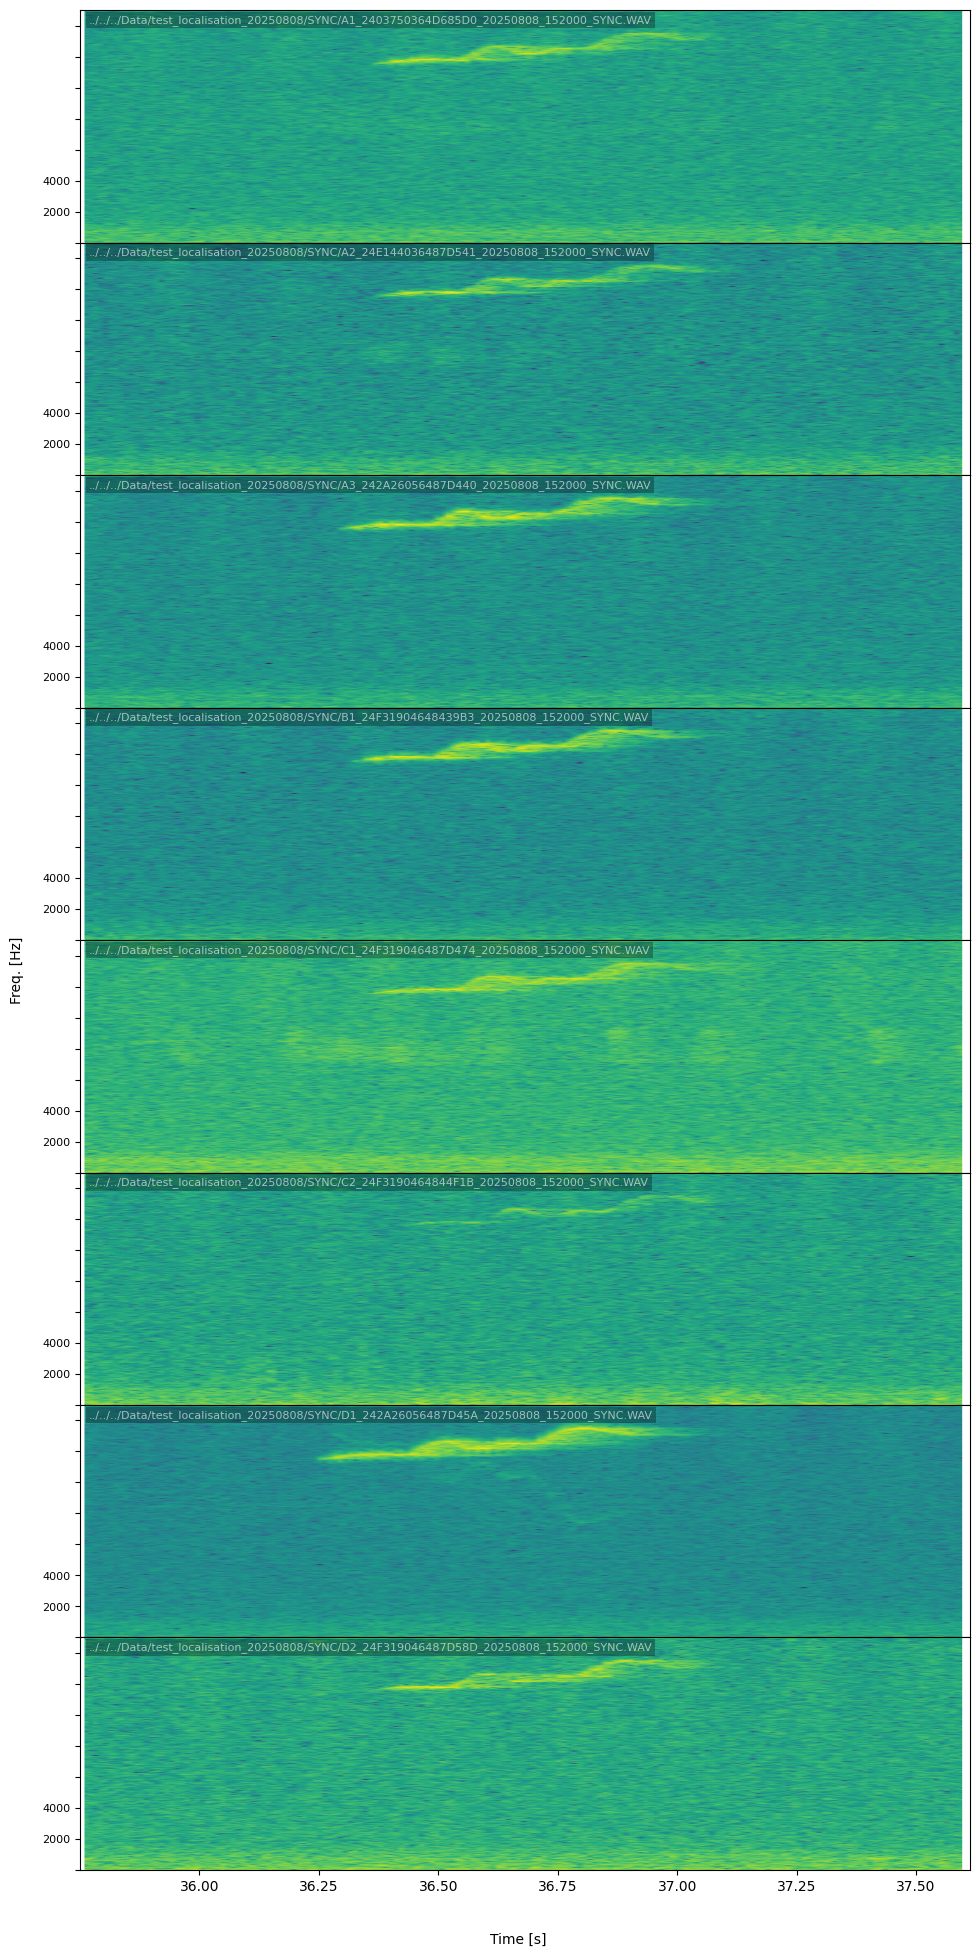

In [121]:
lps.utils.plot_stacked_spectrograms([os.path.join(PATH,f) for f in hearing_files], t_start=start, t_end=stop, fmin= 0, fmax=15000)

Compute TDOAs

In [122]:
signals = lps.signal.load_signals(path=PATH, files_list=hearing_files, start=start, stop=stop)
retards = lps.signal.estimate_tdoa(signals, plot=False, pdf_path="../../results/retards_notebook.pdf")
coef_matrix_pt, tdoa = lps.signal.compute_coef_matrix(retards)

/home/lucas/Documents/Doctorat/Analyses/laplace-soundscape/laplace_soundscape/signal.py:154: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, signal = sp.io.wavfile.read(file_path)


Compute sigmas

Mean sigma value = 0.023


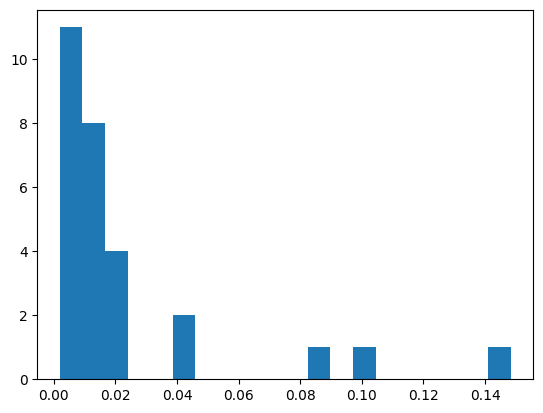

In [123]:
sigmas = [r["cc_peak_width"] for r in retards]
mean_sigma = np.mean(sigmas)
print(f'Mean sigma value = {mean_sigma:.3f}')
plt.hist(sigmas, bins=20)
plt.show()

Center positions

In [124]:
posterior_hearing_array = array.posterior_points.loc[array.posterior_points.index.isin(RECORDERS)]
X_ref_location = posterior_hearing_array["x"].mean()
Y_ref_location = posterior_hearing_array["y"].mean()
posterior_hearing_array.loc[:,"x"] -= X_ref_location
posterior_hearing_array.loc[:,"y"] -= Y_ref_location

Compute posterior sound localization

In [125]:
posterior_trace = lps.spatial.sample_posterior_localization(
    array=np.array(posterior_hearing_array),
    coef_matrix=coef_matrix_pt,
    tdoa=tdoa,
    buffer=50,
    iterations=800,
    sigma=sigmas,
    c=sound_speed,
    method="TDOA"
)

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [x, y]


Output()

Sampling 4 chains for 2_000 tune and 800 draw iterations (8_000 + 3_200 draws total) took 2 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x,-26.519,2.043,-30.427,-22.871,0.074,0.047,781.0,1258.0,1.00
y,-17.993,1.349,-20.424,-15.266,0.049,0.035,775.0,980.0,1.01


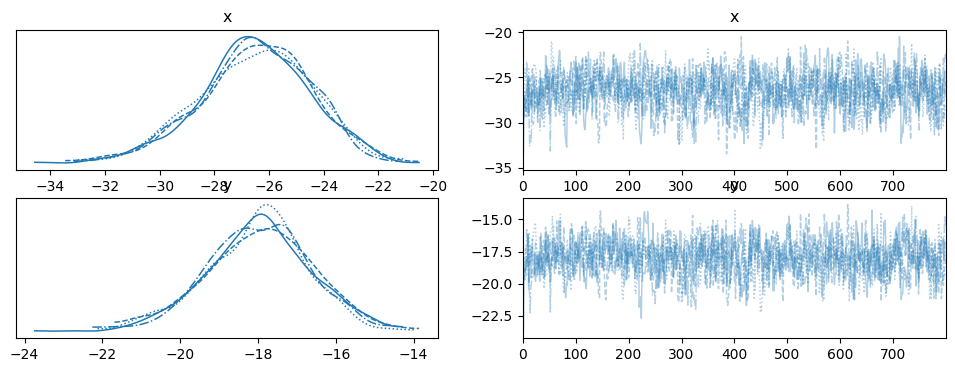

In [126]:
posterior_samples = az.extract(posterior_trace, var_names=["x", "y"]).to_dataframe()
az.plot_trace(posterior_trace, var_names=["x", "y"])
az.summary(posterior_trace, var_names=["x","y"])

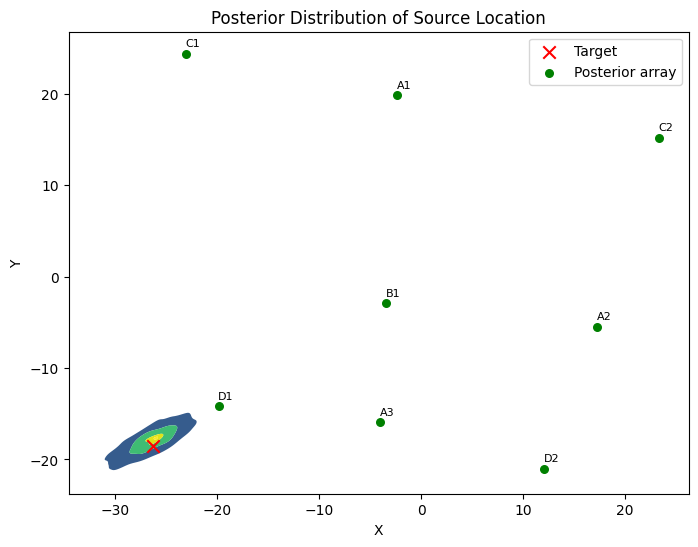

In [127]:
plt.figure(figsize=(8, 6))
# az.plot_kde(prior_samples["x"], prior_samples["y"], contour_kwargs={"alpha": 0},hdi_probs=[.01,.1,.5,.95])
az.plot_kde(posterior_samples["x"], posterior_samples["y"], contour_kwargs={"alpha": 0},hdi_probs=[.01,.1,.5,.89])
plt.scatter(point_posterior_array[0]-X_ref_location,point_posterior_array[1]-Y_ref_location, marker="x", label="Target", s=80, c="red")
plt.scatter(posterior_hearing_array["x"], posterior_hearing_array["y"], color="green", s=30, label="Posterior array")
for idx, (x, y) in posterior_hearing_array.iterrows():
    plt.annotate(str(idx), (x, y), textcoords="offset points", xytext=(5, 5), ha='center', fontsize=8)
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Posterior Distribution of Source Location")
plt.savefig(f"../results/figures/localization_{selection.value}.png", dpi=300, bbox_inches="tight")
plt.show(block=False)

In [128]:
spatial_posterior = lps.spatial.SpatialPosterior(posterior_samples.x, posterior_samples.y, TARGET_EPSG)
print(spatial_posterior.mode())

POINT (-26.08873492260613 -17.63046758708166)


In [129]:
from shapely.geometry import Point
distance_from_target = spatial_posterior.mode().distance(Point(point_posterior_array[0]-X_ref_location,point_posterior_array[1]-Y_ref_location))
print(f'Distance from target = {distance_from_target: .2f} m')

Distance from target =  0.95 m
